In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

In [2]:
iris_df = pd.read_csv("iris.csv")
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris_df.shape

(150, 5)

In [6]:
X_iris = iris_df.drop('species', axis = 1)
y_iris = iris_df['species']


X_train_i,X_test_i,y_train_i,y_test_i = train_test_split(X_iris, y_iris, test_size = 0.2, random_state = 42)

scaler = StandardScaler()

X_train_i = scaler.fit_transform(X_train_i)
X_test_i = scaler.transform(X_test_i)

k_values = range(1,15)
accuracies = []

print("--- Comparing Different K Values ---")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_i, y_train_i)
    y_pred_k = knn.predict(X_test_i)
    acc = accuracy_score(y_test_i, y_pred_k)
    accuracies.append(acc)
    print(f"K={k}: Accuracy = {acc:.4f}")





--- Comparing Different K Values ---
K=1: Accuracy = 1.0000
K=2: Accuracy = 1.0000
K=3: Accuracy = 1.0000
K=4: Accuracy = 1.0000
K=5: Accuracy = 1.0000
K=6: Accuracy = 1.0000
K=7: Accuracy = 1.0000
K=8: Accuracy = 1.0000
K=9: Accuracy = 1.0000
K=10: Accuracy = 1.0000
K=11: Accuracy = 1.0000
K=12: Accuracy = 1.0000
K=13: Accuracy = 1.0000
K=14: Accuracy = 1.0000


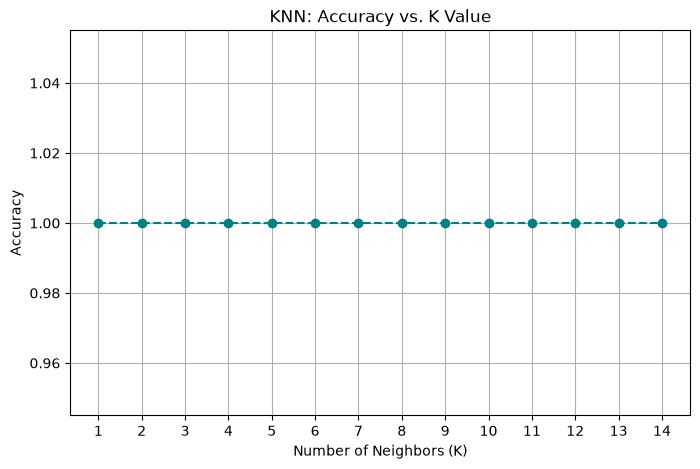

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='teal')
plt.title('KNN: Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [8]:
best_k = 3
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_i, y_train_i)
y_pred_best = best_knn.predict(X_test_i)

In [10]:
precision = precision_score(y_test_i, y_pred_best, average='macro')
recall = recall_score(y_test_i, y_pred_best, average='macro')


--- Detailed Evaluation for K=3 ---
Accuracy:  1.0000
Precision (Macro): 1.0000
Recall (Macro):    1.0000

--- Confusion Matrix ---


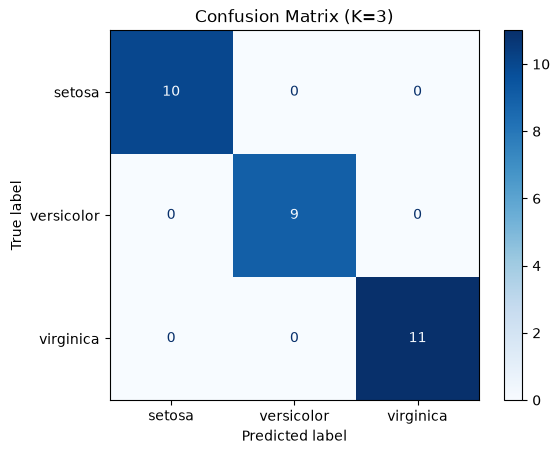

In [11]:
print(f"\n--- Detailed Evaluation for K={best_k} ---")
print(f"Accuracy:  {accuracy_score(y_test_i, y_pred_best):.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro):    {recall:.4f}")


print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_i, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={best_k})')
plt.show()